<a href="https://colab.research.google.com/github/javendaXgh/ucveconomiaestadistica1-2-2025/blob/main/notebooks/notebook2_apoyo_ejercicio_estadistica_i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalamos las librerías si no están presentes
if (!require("readxl")) install.packages("readxl") # Para guardar excel con datos
if (!require("writexl")) install.packages("writexl") # Para escribir el excel

# Cargar librerias necesarias
library(tidyverse)
library(readxl)
library(writexl)


Loading required package: readxl

Loading required package: writexl

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
if (!require("fdth")) install.packages("fdth") # Para procesar las tablas de frecuencia
library(fdth)

Loading required package: fdth


Attaching package: ‘fdth’


The following objects are masked from ‘package:stats’:

    sd, var




In [3]:
if (!require("pdfetch")) install.packages("pdfetch") # Para procesar los datos
library(pdfetch)

Loading required package: pdfetch

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘pdfetch’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘TTR’, ‘xts’, ‘XML’, ‘quantmod’




In [6]:
# Descargar precios (ej. Apple )

# "from"= desde
# "to" = hasta
datos_financieros <- pdfetch_YAHOO(c("AAPL",
                                    "GC=F",
                                    "IBM"),
                                  from = "2023-01-01",
                                  to   = "2025-12-31")



Warning message:
“GC=F contains missing values. Some functions will not work if objects contain missing values in the middle of the series. Consider using na.omit(), na.approx(), na.fill(), etc to remove or replace them.”


In [ ]:
# Descargar precios mensuales
# Descargar precios (ej. Apple y Futuros de Oro)

# "from"= desde
# "to" = hasta

# tickets identificadores
# c("AAPL","GC=F","IBM")
# listado tickets en https://finance.yahoo.com/markets/

datos_financieros <- pdfetch_YAHOO(c("AAPL",
                                    "GC=F",
                                    "IBM"),
                                  from = "2023-01-01",
                                  to   = "2025-12-31")


In [7]:
# ver contenido de la descarga
datos_financieros

           AAPL.open AAPL.high AAPL.low AAPL.close AAPL.adjclose AAPL.volume
2023-01-03    130.28    130.90   124.17     125.07      123.2112   112117500
2023-01-04    126.89    128.66   125.08     126.36      124.4820    89113600
2023-01-05    127.13    127.77   124.76     125.02      123.1619    80962700
2023-01-06    126.01    130.29   124.89     129.62      127.6936    87754700
2023-01-09    130.47    133.41   129.89     130.15      128.2157    70790800
2023-01-10    130.26    131.26   128.12     130.73      128.7871    63896200
2023-01-11    131.25    133.51   130.46     133.49      131.5061    69458900
2023-01-12    133.88    134.26   131.44     133.41      131.4273    71379600
2023-01-13    132.03    134.92   131.66     134.76      132.7572    57809700
2023-01-17    134.83    137.29   134.13     135.94      133.9197    63646600
       ...                                                                  
2025-12-16    272.82    275.50   271.79     274.61      274.6100    37648600

In [8]:
# ver cantidad de observaciones

nrow(datos_financieros)

[1] 756

In [9]:
# Descargar precios (ej. Apple y Futuros de Oro)
# periodididad mensual. opciones "1d", "1wk", "1mo", "daily", "weekly", "monthly"
# interval="monthly"  mensual

datos_financieros <- pdfetch_YAHOO(c("AAPL",
                                    "GC=F",
                                    "IBM"),
                                  from = "2023-01-01",
                                  to   = "2025-12-31",
                                  interval='monthly')

In [10]:
# ver contenido de la descarga
datos_financieros

           AAPL.open AAPL.high AAPL.low AAPL.close AAPL.adjclose AAPL.volume
2023-01-01    130.28    147.23   124.17     144.29      142.1455  1443652500
2023-02-01    143.97    157.38   141.32     147.41      145.2192  1307198900
2023-03-01    146.83    165.00   143.90     164.90      162.6973  1520266600
2023-04-01    164.27    169.85   159.78     169.68      167.4134   969776400
2023-05-01    169.28    179.35   164.31     177.25      174.8823  1275364700
2023-06-01    177.70    194.48   176.93     193.97      191.6437  1297383300
2023-07-01    193.78    198.23   186.60     196.45      194.0939   996114000
2023-08-01    196.24    196.73   171.96     187.87      185.6168  1322657800
2023-09-01    189.49    189.98   167.62     171.21      169.3851  1337823000
2023-10-01    171.22    182.34   165.67     170.77      168.9498  1172816900
2023-11-01    171.00    192.93   170.12     189.95      187.9253  1099651600
2023-12-01    190.33    199.62   187.45     192.53      190.7288  1063181200

In [14]:
# Descargar precios (ej. Apple y Futuros de Oro)

# fields c("open", "high", "low", "close", "adjclose", "volume"),

datos_financieros <- pdfetch_YAHOO("AAPL",
                                  from = "2023-01-01",
                                  to   = "2025-12-31",
                                  interval='monthly',
                                  fields= c("open", "volume"))

In [15]:
# ver contenido de la descarga
datos_financieros

           AAPL.open AAPL.volume
2023-01-01    130.28  1443652500
2023-02-01    143.97  1307198900
2023-03-01    146.83  1520266600
2023-04-01    164.27   969776400
2023-05-01    169.28  1275364700
2023-06-01    177.70  1297383300
2023-07-01    193.78   996114000
2023-08-01    196.24  1322657800
2023-09-01    189.49  1337823000
2023-10-01    171.22  1172816900
2023-11-01    171.00  1099651600
2023-12-01    190.33  1063181200
2024-01-01    187.15  1187490800
2024-02-01    183.99  1161553500
2024-03-01    179.55  1433151800
2024-04-01    171.19  1246144100
2024-05-01    169.58  1336511300
2024-06-01    192.90  1717952100
2024-07-01    212.09  1153099800
2024-08-01    224.37  1122667000
2024-09-01    228.55  1232097700
2024-10-01    229.52   930736000
2024-11-01    220.97   891588300
2024-12-01    237.27   977916100
2025-01-01    248.93  1200176400
2025-02-01    229.99   862272300
2025-03-01    241.79  1115239500
2025-04-01    219.81  1607318600
2025-05-01    209.08  1195728200
2025-06-01

In [16]:
# Ver el resultado (es un data frame normal)
head(datos_financieros)

           AAPL.open AAPL.volume
2023-01-01    130.28  1443652500
2023-02-01    143.97  1307198900
2023-03-01    146.83  1520266600
2023-04-01    164.27   969776400
2023-05-01    169.28  1275364700
2023-06-01    177.70  1297383300

In [17]:
#datos_financieros%>%
#  filter(symbol=="GC=F" )

In [ ]:
# no es necesario compender a fondo esté código
procesar_precios_mensuales <- function(datos) {

  datos %>%
    # 1. Crear una columna que represente el mes (redondeando la fecha hacia abajo)
    mutate(mes = floor_date(date, unit = "month")) %>%

    # 2. Agrupar por el símbolo (acción/commodity) y por el mes
    group_by(symbol, mes) %>%

    # 3. Calcular el promedio del precio de cierre (close)
    summarise(precio_promedio = mean(close, na.rm = TRUE), .groups = "drop") %>%

    # 4. Transformar: Los símbolos se vuelven columnas
    pivot_wider(names_from = symbol, values_from = precio_promedio)

}

In [ ]:
procesar_precios_mensuales(datos_financieros)

In [19]:

# 2. Generamos la tabla de frecuencia sobre el precio de cierre ('close')
# fdt = Frequency Distribution Table
tabla_distribucion_apple <- fdt(datos_financieros$AAPL.open, breaks = "Sturges")

# 3. Ver la tabla
print(tabla_distribucion_apple)

      Class limits f   rf rf(%) cf  cf(%)
 [128.977,150.665) 3 0.08  8.33  3   8.33
 [150.665,172.352) 6 0.17 16.67  9  25.00
  [172.352,194.04) 8 0.22 22.22 17  47.22
  [194.04,215.727) 6 0.17 16.67 23  63.89
 [215.727,237.415) 8 0.22 22.22 31  86.11
 [237.415,259.103) 3 0.08  8.33 34  94.44
  [259.103,280.79) 2 0.06  5.56 36 100.00


In [20]:
tabla_custom_apple <- fdt(datos_financieros$AAPL.open, k = 4)
tabla_custom_apple

Class limits,f,rf,rf(%),cf,cf(%)
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
"[128.977,166.93)",4,0.1111111,11.11111,4,11.11111
"[166.93,204.884)",15,0.4166667,41.66667,19,52.77778
"[204.884,242.837)",13,0.3611111,36.11111,32,88.88889
"[242.837,280.79)",4,0.1111111,11.11111,36,100.00000


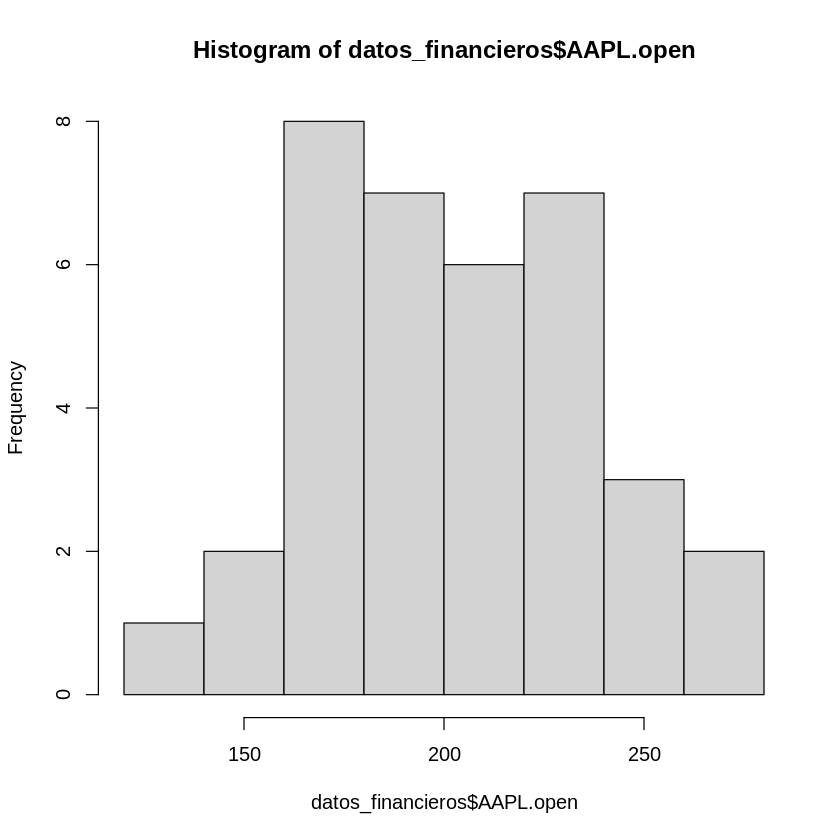

In [23]:
hist(datos_financieros$AAPL.open)

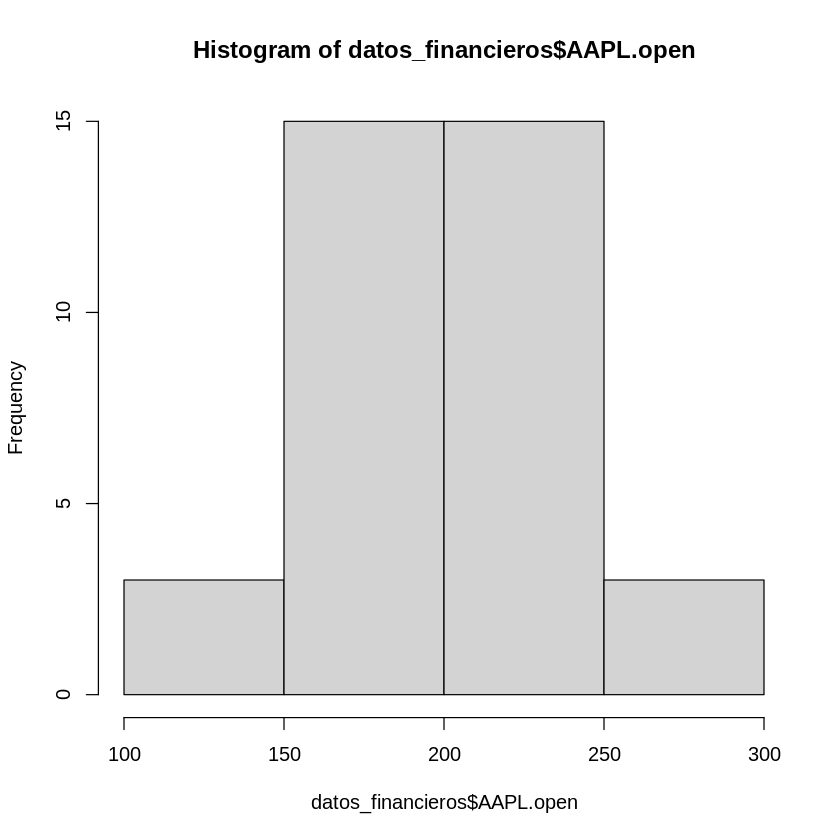

In [24]:
hist(datos_financieros$AAPL.open, breaks = 4)

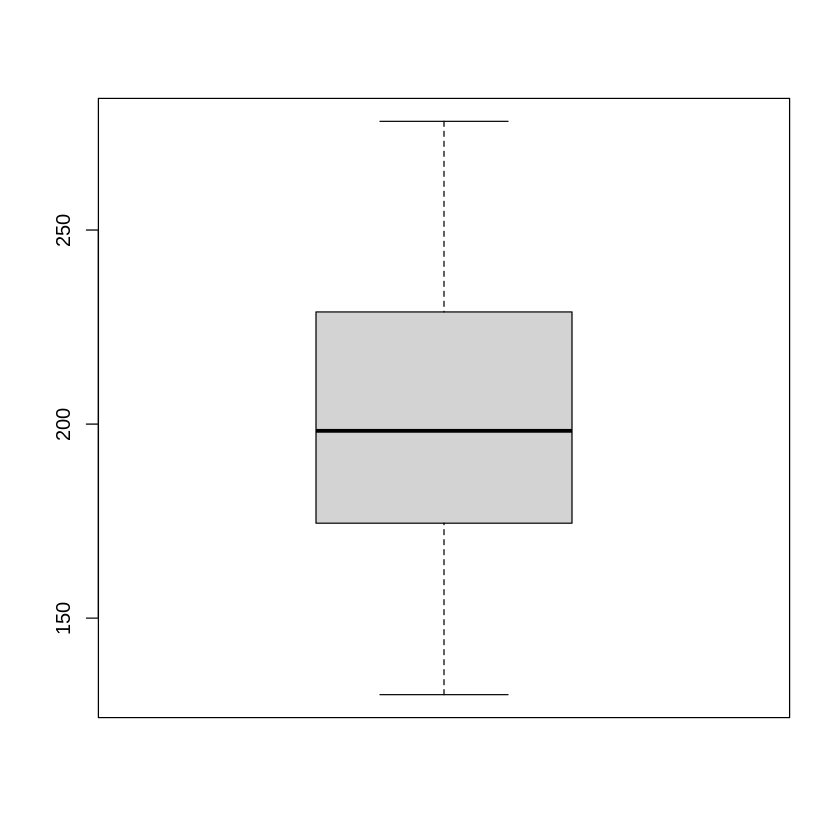

In [22]:
boxplot(datos_financieros$AAPL.open)

In [ ]:
# 1. Bajar datos
df_oro <- tq_get("GC=F", from = "2023-01-01")
df_oro <-  pdfetch_YAHOO("GC=F",
                         from = "2023-01-01",
                         to   = "2025-12-31",
                         interval='monthly',
                         fields= c("open", "volume"))


# 2. Guardar en Excel
write_xlsx(df_oro, "precios_oro.xlsx")

## Importar datos

In [ ]:
# Leer el archivo excel
# Asegúrate de que el nombre coincida con el archivo que subiste
df <- read_excel("datos.xlsx", sheet = 1)

# Ver las primeras filas para confirmar
head(df)

## Valores estadísticos

In [25]:
summary(datos_financieros$AAPL.open)

     Index              AAPL.open    
 Min.   :2023-01-01   Min.   :130.3  
 1st Qu.:2023-09-23   1st Qu.:176.1  
 Median :2024-06-16   Median :198.3  
 Mean   :2024-06-16   Mean   :202.3  
 3rd Qu.:2025-03-08   3rd Qu.:228.7  
 Max.   :2025-12-01   Max.   :278.0  

In [26]:
sd(datos_financieros$AAPL.open)

[1] 34.96679